# House Prices: Advanced Regression Techniques

This notebook tackles the [Kaggle House Prices](https://www.kaggle.com/c/house-prices-advanced-regression-techniques) competition.
The goal is to predict residential home sale prices in Ames, Iowa using 79 explanatory variables.

**Pipeline overview:**
1. Load train/test data
2. Exploratory data analysis and outlier removal
3. Missing value imputation
4. Feature engineering (age, area composites, polynomial features)
5. Model training and ensembling (Lasso, ElasticNet, KernelRidge, GBM, XGBoost, LightGBM)
6. Generate submission

## 1. Imports and Data Loading

## 2. Initial Data Exploration

In [1]:
import numpy as np
import pandas as pd
import os

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [2]:
train_df=pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
test_df=pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [4]:
train_df.info()
print('-' * 40)
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 3. Target Variable Transformation

Apply `log1p` to `SalePrice` to reduce right skew and make the distribution closer to normal.

## 4. Outlier Removal

Remove training samples with very large above-grade living area (`GrLivArea > 4000`) that are priced unusually low — these are likely data anomalies.

In [5]:
train_df['SalePrice']= np.log1p(train_df['SalePrice'])


In [6]:
train_df = train_df.drop(train_df[(train_df['GrLivArea']>4000) & (train_df['SalePrice']<300000)].index)

## 5. Missing Value Imputation

Handle missing values across both train and test sets:
- Categorical features with a dominant value are filled with the mode.
- Features where `NaN` semantically means "None" (e.g. no alley, no pool) are filled with `'None'`.
- Numeric area/count features default to `0` when no corresponding structure exists.

### 5a. Categorical Missing Values (Mode Imputation)

In [7]:
train_df['Electrical'] = train_df['Electrical'].fillna(train_df['Electrical'].mode()[0])
test_df['Exterior1st'] = test_df['Exterior1st'].fillna(test_df['Exterior1st'].mode()[0])
test_df['Exterior2nd'] = test_df['Exterior2nd'].fillna(test_df['Exterior2nd'].mode()[0])
test_df['KitchenQual'] = test_df['KitchenQual'].fillna(test_df['KitchenQual'].mode()[0])
test_df['Functional'] = test_df['Functional'].fillna(test_df['Functional'].mode()[0])
test_df['SaleType'] = test_df['SaleType'].fillna(test_df['SaleType'].mode()[0])
test_df['MSZoning'] = test_df['MSZoning'].fillna(test_df['MSZoning'].mode()[0])

In [8]:
train_df.loc[(train_df['MasVnrType'].isnull()) & (train_df['MasVnrArea'] == 0), 'MasVnrType'] = 'None'
train_df.loc[(train_df['MasVnrType'].isnull()) & (train_df['MasVnrArea'].isnull()), ('MasVnrType', 'MasVnrArea')] = 'None' , 0
count_missing_mas_vnr = train_df[(train_df['MasVnrArea'].isnull()) & (train_df['MasVnrType'].isnull())].shape[0]
print(count_missing_mas_vnr)
print(train_df[train_df['MasVnrType'] == 'None'].shape[0])
train_df['MasVnrType'] = train_df['MasVnrType'].fillna(train_df.loc[train_df['MasVnrType'] != 'None', 'MasVnrType'].mode()[0])
print(train_df[train_df['MasVnrType'] == 'None'].shape[0])
train_df['MasVnrType'].info()
train_df['MasVnrArea'].info()

0
866
866
<class 'pandas.core.series.Series'>
Index: 1456 entries, 0 to 1459
Series name: MasVnrType
Non-Null Count  Dtype 
--------------  ----- 
1456 non-null   object
dtypes: object(1)
memory usage: 22.8+ KB
<class 'pandas.core.series.Series'>
Index: 1456 entries, 0 to 1459
Series name: MasVnrArea
Non-Null Count  Dtype  
--------------  -----  
1456 non-null   float64
dtypes: float64(1)
memory usage: 22.8 KB


In [9]:
test_df.loc[(test_df['MasVnrType'].isnull()) & (test_df['MasVnrArea'] == 0), 'MasVnrType'] = 'None'
test_df.loc[(test_df['MasVnrType'].isnull()) & (test_df['MasVnrArea'].isnull()), ('MasVnrType', 'MasVnrArea')] = 'None' , 0
count_missing_mas_vnr = test_df[(test_df['MasVnrArea'].isnull()) & (test_df['MasVnrType'].isnull())].shape[0]
print(count_missing_mas_vnr)
print(test_df[test_df['MasVnrType'] == 'None'].shape[0])
test_df['MasVnrType'] = test_df['MasVnrType'].fillna(test_df.loc[test_df['MasVnrType'] != 'None', 'MasVnrType'].mode()[0])
print(test_df[test_df['MasVnrType'] == 'None'].shape[0])
test_df['MasVnrType'].info()
test_df['MasVnrArea'].info()

0
891
891
<class 'pandas.core.series.Series'>
RangeIndex: 1459 entries, 0 to 1458
Series name: MasVnrType
Non-Null Count  Dtype 
--------------  ----- 
1459 non-null   object
dtypes: object(1)
memory usage: 11.5+ KB
<class 'pandas.core.series.Series'>
RangeIndex: 1459 entries, 0 to 1458
Series name: MasVnrArea
Non-Null Count  Dtype  
--------------  -----  
1459 non-null   float64
dtypes: float64(1)
memory usage: 11.5 KB


In [10]:
train_df = train_df.drop(columns=['Utilities', 'Id'])
test_df = test_df.drop(columns=['Utilities'])

In [11]:
train_df['Alley'] = train_df['Alley'].fillna('None')
train_df['PoolQC'] = train_df['PoolQC'].fillna('None')
train_df['Fence'] = train_df['Fence'].fillna('None')
train_df['MiscFeature'] = train_df['MiscFeature'].fillna('None')

test_df['Alley'] = test_df['Alley'].fillna('None')
test_df['PoolQC'] = test_df['PoolQC'].fillna('None')
test_df['Fence'] = test_df['Fence'].fillna('None')
test_df['MiscFeature'] = test_df['MiscFeature'].fillna('None')

### 5b. Structural Absence Features

For features where `NaN` means the structure does not exist (alley, pool, fence, etc.), fill with `'None'`.

### 5c. Garage Feature Imputation

For rows that have a garage (non-zero `GarageArea`) but missing garage metadata, impute with the column mode.

In [14]:
train_df.loc[train_df['TotalBsmtSF'] == 0, ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']] = 'None'
train_df.loc[train_df['TotalBsmtSF'] == 0, ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'BsmtFullBath', 'BsmtHalfBath']] = 0
train_df['BsmtExposure'] = train_df['BsmtExposure'].fillna(train_df['BsmtExposure'].mode()[0])
train_df['BsmtFinType2'] = train_df['BsmtFinType2'].fillna(train_df['BsmtFinType2'].mode()[0])

In [15]:
test_df['TotalBsmtSF'] = test_df['TotalBsmtSF'].fillna(0)
test_df.loc[test_df['TotalBsmtSF'] == 0, ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']] = 'None'
test_df.loc[test_df['TotalBsmtSF'] == 0, ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'BsmtFullBath', 'BsmtHalfBath']] = 0
test_df['BsmtExposure'] = test_df['BsmtExposure'].fillna(test_df['BsmtExposure'].mode()[0])
test_df['BsmtFinType2'] = test_df['BsmtFinType2'].fillna(test_df['BsmtFinType2'].mode()[0])
test_df['BsmtQual'] = test_df['BsmtQual'].fillna(test_df['BsmtQual'].mode()[0])
test_df['BsmtCond'] = test_df['BsmtCond'].fillna(test_df['BsmtCond'].mode()[0])

In [20]:
train_df['GarageYrBlt'] = train_df.apply(lambda row: train_df['GarageYrBlt'].mode()[0] if pd.notna(row['GarageArea']) and pd.isna(row['GarageYrBlt']) else row['YrSold'], axis=1)
train_df['GarageType'] = train_df.apply(lambda row: train_df['GarageType'].mode()[0] if pd.notna(row['GarageArea']) and pd.isna(row['GarageType']) else row['YrSold'], axis=1)
train_df['GarageFinish'] = train_df.apply(lambda row: train_df['GarageFinish'].mode()[0] if pd.notna(row['GarageArea']) and pd.isna(row['GarageFinish']) else row['YrSold'], axis=1)
train_df['GarageQual'] = train_df.apply(lambda row: train_df['GarageQual'].mode()[0] if pd.notna(row['GarageArea']) and pd.isna(row['GarageQual']) else row['YrSold'], axis=1)
train_df['GarageCond'] = train_df.apply(lambda row: train_df['GarageCond'].mode()[0] if pd.notna(row['GarageArea']) and pd.isna(row['GarageQual']) else row['YrSold'], axis=1)


In [21]:
test_df['GarageYrBlt'] = test_df.apply(lambda row: test_df['GarageYrBlt'].mode()[0] if pd.notna(row['GarageArea']) and pd.isna(row['GarageYrBlt']) else row['YrSold'], axis=1)
test_df['GarageType'] = test_df.apply(lambda row: test_df['GarageType'].mode()[0] if pd.notna(row['GarageArea']) and pd.isna(row['GarageType']) else row['YrSold'], axis=1)
test_df['GarageFinish'] = test_df.apply(lambda row: test_df['GarageFinish'].mode()[0] if pd.notna(row['GarageArea']) and pd.isna(row['GarageFinish']) else row['YrSold'], axis=1)
test_df['GarageQual'] = test_df.apply(lambda row: test_df['GarageQual'].mode()[0] if pd.notna(row['GarageArea']) and pd.isna(row['GarageQual']) else row['YrSold'], axis=1)
test_df['GarageCond'] = test_df.apply(lambda row: test_df['GarageCond'].mode()[0] if pd.notna(row['GarageArea']) and pd.isna(row['GarageQual']) else row['YrSold'], axis=1)


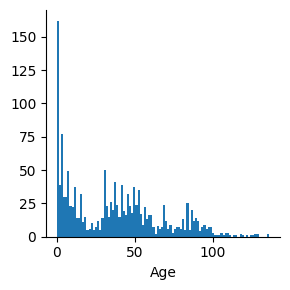

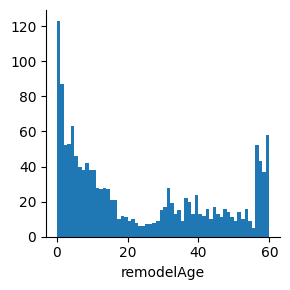

In [22]:
train_df['Age'] = train_df['YrSold'] - train_df['YearBuilt']
train_df['remodelAge'] = train_df['YrSold'] - train_df['YearRemodAdd']

test_df['Age'] = test_df['YrSold'] - test_df['YearBuilt']
test_df['remodelAge'] = test_df['YrSold'] - test_df['YearRemodAdd']

g = sns.FacetGrid(train_df)
g.map(plt.hist, 'Age', bins=100)
g = sns.FacetGrid(train_df)
g.map(plt.hist, 'remodelAge', bins=60)

## 7. Derived Numeric Features

Engineer composite numeric features to capture garage efficiency and total living area.

## 8. LotFrontage Imputation via Random Forest

LotFrontage has many missing values. Instead of simple mean/median imputation, a `RandomForestRegressor` is trained on rows where LotFrontage is observed and used to predict missing values in both train and test sets.

In [23]:
train_df['FireplaceQu'] = train_df['FireplaceQu'].fillna(train_df['FireplaceQu'].mode()[0])

test_df['FireplaceQu'] = test_df['FireplaceQu'].fillna(test_df['FireplaceQu'].mode()[0])

## 6. Temporal Feature Engineering

Create age-based features from the year columns:
- `Age`: years since the house was built at time of sale
- `remodelAge`: years since the last remodel

In [27]:
train_df['GarageArea'] = train_df['GarageArea'].fillna(0)
train_df['GarageCars'] = train_df['GarageCars'].fillna(0)

train_df['SpacePerCar'] = train_df.apply(lambda row: row['GarageArea'] / row['GarageCars'] 
                             if row['GarageCars'] > 0 else 0, axis=1)

### 7a. Total Area Composites

### 7b. Area Composites (Train + Test)

Create `TotalArea`, `TotalSf`, and `TotalSpace` to summarise all living space in a single figure.

In [28]:
test_df['GarageArea'] = test_df['GarageArea'].fillna(0)
test_df['GarageCars'] = test_df['GarageCars'].fillna(0)

test_df['SpacePerCar'] = test_df.apply(lambda row: row['GarageArea'] / row['GarageCars'] 
                             if row['GarageCars'] > 0 else 0, axis=1)

### 7a. Total Area Composites (Test Set)

*(Applied identically to test data above)*

In [32]:
train_df['TotalArea'] = train_df['GrLivArea'] + train_df['TotalBsmtSF'] + train_df['GarageArea']
test_df['TotalArea'] = test_df['GrLivArea'] + test_df['TotalBsmtSF'] + test_df['GarageArea']

train_df["TotalSf"] = train_df['TotalBsmtSF'] + train_df['1stFlrSF'] + train_df['2ndFlrSF']
test_df["TotalSf"] = test_df['TotalBsmtSF'] + test_df['1stFlrSF'] + test_df['2ndFlrSF']

train_df['TotalSpace'] = train_df["TotalSf"] + train_df['TotalArea']
test_df['TotalSpace'] = test_df["TotalSf"] + test_df['TotalArea']

In [37]:
from sklearn.ensemble import RandomForestRegressor

# Prepare data for regression model
train_df_with_lot_frontage = train_df[train_df['LotFrontage'].notna()]
train_df_without_lot_frontage = train_df[train_df['LotFrontage'].isna()]

test_df_without_lot_frontage = test_df[test_df['LotFrontage'].isna()]

# Select features for training
X = train_df_with_lot_frontage[train_df_with_lot_frontage.columns].copy()
y = train_df_with_lot_frontage['LotFrontage']
X = X.drop(columns = ['LotFrontage' , 'SalePrice'])
# One-hot encoding for categorical variables
X = pd.get_dummies(X, drop_first=True)

# Fit the model
model = RandomForestRegressor()
model.fit(X, y)

# Prepare data for prediction
X_train_missing = train_df_without_lot_frontage[train_df_without_lot_frontage.columns].copy()
X_train_missing = X_train_missing.drop(columns = ['LotFrontage' , 'SalePrice'])
X_train_missing = pd.get_dummies(X_train_missing)
X_train_missing = X_train_missing.reindex(columns=X.columns, fill_value=0)

X_test_missing = test_df_without_lot_frontage[test_df_without_lot_frontage.columns].copy()
X_test_missing = X_test_missing.drop(columns = ['LotFrontage'])
X_test_missing = pd.get_dummies(X_test_missing)
X_test_missing = X_test_missing.reindex(columns=X.columns, fill_value=0)
# Predict missing LotFrontage values
predicted_lot_frontage = model.predict(X_train_missing)
predicted_lot_frontage2 = model.predict(X_test_missing)

# Fill the missing values in LotFrontage
train_df.loc[train_df['LotFrontage'].isna(), 'LotFrontage'] = predicted_lot_frontage
test_df.loc[test_df['LotFrontage'].isna(), 'LotFrontage'] = predicted_lot_frontage2

## 9. LotArea Outlier Treatment

Houses with `LotArea > 20000` sqft are rare outliers. A `RandomForestRegressor` is trained on the in-distribution portion of the data and used to replace the extreme values.

In [38]:
from sklearn.ensemble import RandomForestRegressor

# LA_Q1= np.percentile(train_df['LotArea'],25)
# LA_Q3= np.percentile(train_df['LotArea'],75)
# LA_IQR= LA_Q3 - LA_Q1

# LA_upper_bound = int(LA_Q3 + 1.5 * LA_IQR)
# LA_lower_bound = int(LA_Q1 - 2.5 * LA_IQR)
filtered = train_df[train_df['LotArea'] <= 20000]
LA_X = filtered[filtered.columns]
LA_X = LA_X.drop(columns = ['LotArea', 'SalePrice'])
LA_X = pd.get_dummies(LA_X[LA_X.columns])
LA_y = filtered['LotArea']

LA_model = RandomForestRegressor()
LA_model.fit(LA_X,LA_y)

LA_X2 = train_df[train_df.columns]
LA_X2 = LA_X2.drop(columns = ['LotArea', 'SalePrice'])
LA_X2 = pd.get_dummies(LA_X2[LA_X2.columns])
LA_X2 = LA_X2.reindex(columns=LA_X.columns, fill_value=0)

LA_test_X2 = test_df[test_df.columns]
LA_test_X2 = LA_test_X2.drop(columns = ['LotArea'])
LA_test_X2 = pd.get_dummies(LA_test_X2[LA_test_X2.columns])
LA_test_X2 = LA_test_X2.reindex(columns=LA_X.columns, fill_value=0)

train_df['LotArea'] = np.where(train_df['LotArea'] > 20000, LA_model.predict(LA_X2), train_df['LotArea'])
test_df['LotArea'] = np.where(test_df['LotArea'] > 20000, LA_model.predict(LA_test_X2), test_df['LotArea'])

## 10. Feature Scaling and Visualisation

Standardise `LotArea` (zero mean, unit variance) and inspect scatter plots of key features against `SalePrice`.

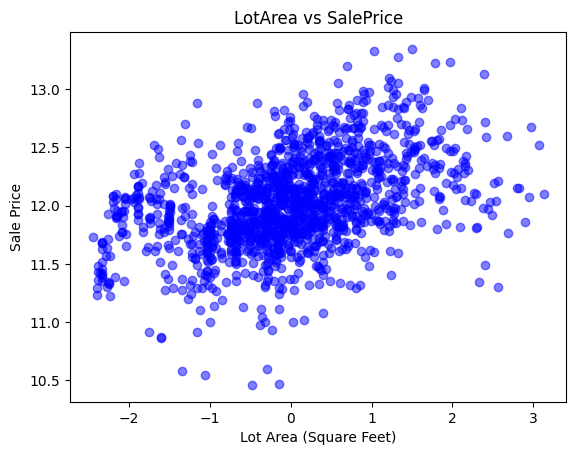

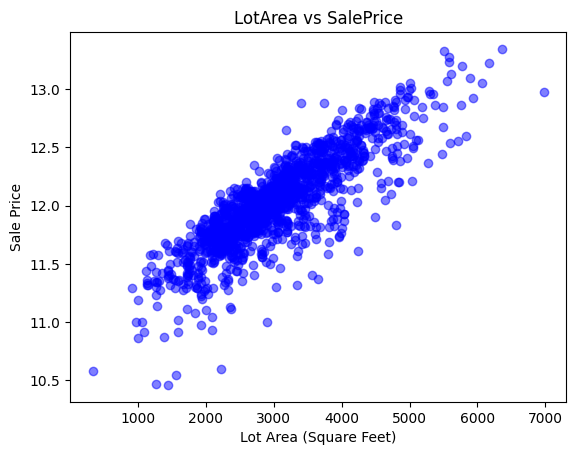

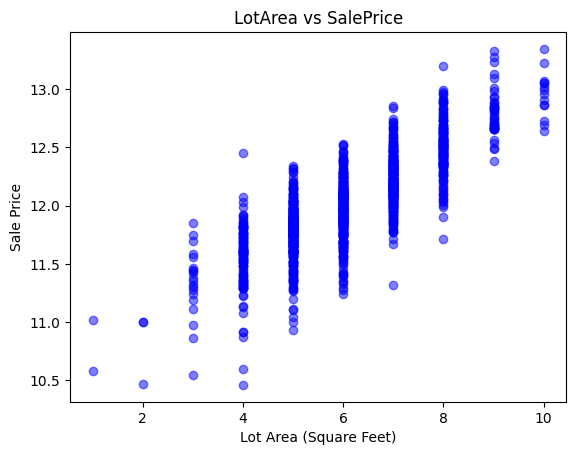

In [40]:
# train_df['LnLotArea']= np.log1p(train_df['LotArea'])

# train_df['LnLotArea']= (train_df['LnLotArea']-train_df['LnLotArea'].mean())/train_df['LnLotArea'].std()
train_df['LotArea']= (train_df['LotArea']-train_df['LotArea'].mean())/train_df['LotArea'].std()
test_df['LotArea']= (test_df['LotArea']-test_df['LotArea'].mean())/test_df['LotArea'].std()

plt.scatter(train_df['LotArea'], train_df['SalePrice'], color='blue', alpha=0.5)
plt.title('LotArea vs SalePrice')
plt.xlabel('Lot Area (Square Feet)')
plt.ylabel('Sale Price')
plt.show()

plt.scatter(train_df['TotalArea'], train_df['SalePrice'], color='blue', alpha=0.5)
plt.title('LotArea vs SalePrice')
plt.xlabel('Lot Area (Square Feet)')
plt.ylabel('Sale Price')
plt.show()

plt.scatter(train_df['OverallQual'], train_df['SalePrice'], color='blue', alpha=0.5)
plt.title('LotArea vs SalePrice')
plt.xlabel('Lot Area (Square Feet)')
plt.ylabel('Sale Price')
plt.show()

# plt.scatter(train_df['LnLotArea'], train_df['SalePrice'], color='blue', alpha=0.5)
# plt.title('LnLotArea vs SalePrice')
# plt.xlabel('LnLot Area (Square Feet)')
# plt.ylabel('Sale Price')
# plt.show()


## 11. Polynomial and Interaction Features

Add squared and cubed terms for the most predictive area features, plus a `LotRatio` interaction term.

In [41]:
train_df['TotalArea**2'] = train_df['TotalArea'] ** 2
test_df['TotalArea**2'] = test_df['TotalArea'] ** 2

train_df['TotalArea**3'] = train_df['TotalArea'] ** 3
test_df['TotalArea**3'] = test_df['TotalArea'] ** 3

train_df['TotalSf**2'] = train_df['TotalSf'] ** 2
test_df['TotalSf**2'] = test_df['TotalSf'] ** 2

train_df['TotalSpace**2'] = train_df['TotalSpace'] ** 2
test_df['TotalSpace**2'] = test_df['TotalSpace'] ** 2

train_df['OverallQual**2'] = train_df['OverallQual'] ** 2
test_df['OverallQual**2'] = test_df['OverallQual'] ** 2

train_df['LotRatio'] = train_df['LotFrontage'] / train_df['LotArea']
test_df['LotRatio'] = test_df['LotFrontage'] / test_df['LotArea']


# train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

## 12. Data Preparation for Modelling

One-hot encode categorical variables, drop the target, and align train/test feature columns.

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

train_df.dropna(axis=1)
X = pd.get_dummies(train_df[train_df.columns])
X = pd.get_dummies(X,columns=['MSSubClass' , 'MoSold'])
X = X.drop(columns=['SalePrice'])
# for col in X.columns:
#     print(col)
y = train_df.SalePrice.values

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)


model = GradientBoostingRegressor(learning_rate=0.01, n_estimators=500, random_state = 42)
model.fit(X,y)
rmse_scorer = make_scorer(mean_squared_error, greater_is_better=False, squared=False)
# cv_scores = cross_val_score(model, X, y, cv=5,scoring=rmse_scorer)
# cv_scores2 = cross_val_score(model2, X, y, cv=5,scoring=rmse_scorer)

print(model.score(X_valid,y_valid))

# Print the results
# print("Cross-Validation Scores:", cv_scores)
# print("Average CV Score:", cv_scores.mean())

# print("Cross-Validation Scores:", cv_scores2)
# print("Average CV Score:", cv_scores2.mean())

test_df.dropna(axis=1)
X2 = pd.get_dummies(test_df[test_df.columns])
X2 = pd.get_dummies(X2,columns=['MSSubClass' , 'MoSold'])
X2 = X2.drop(columns=['Street_Grvl'])
ids = X2.pop('Id')

X2 = X2.reindex(columns=X.columns, fill_value=0)


# preds = model.predict(X2)
# output = pd.DataFrame({'Id': ids,
#                        'SalePrice': preds.squeeze()})
# output.to_csv('submission.csv', index=False)
# output.head()

importances = model.feature_importances_

# Sort feature importances
sorted_indices = np.argsort(importances)[::-1]

# Print feature importance
for idx in sorted_indices:
    print(f"{X.columns[idx]}: {importances[idx]}")


0.9301923128153197
OverallQual: 0.17442983970656945
OverallQual**2: 0.1456528986435887
TotalArea: 0.13654351671941833
TotalArea**3: 0.11719535373382248
TotalArea**2: 0.1016821221600231
TotalSpace: 0.058597471052521014
TotalSpace**2: 0.05703568099638097
remodelAge: 0.01838662101772495
OverallCond: 0.015440071788302855
Fireplaces: 0.014913325073180477
GrLivArea: 0.013601234609287687
YearBuilt: 0.012245864060405644
Age: 0.011350114394060596
BsmtFinSF1: 0.010497705826375226
YearRemodAdd: 0.010077561628516274
TotalSf: 0.007418081223601811
LotArea: 0.007250670699418416
CentralAir_Y: 0.006598614633233523
TotalSf**2: 0.006443014766281793
MSZoning_C (all): 0.006305980882317185
KitchenQual_TA: 0.005896988685429039
MSZoning_RL: 0.0056284465812428235
MSZoning_RM: 0.005433163554478607
CentralAir_N: 0.005129379145352797
1stFlrSF: 0.0039433035090083455
KitchenAbvGr: 0.003242016715921045
GarageCars: 0.002972299967620633
Neighborhood_Crawfor: 0.0026403579772057745
MSSubClass_60: 0.002621657880163352
Sa

## 13. Advanced Model Definitions

Define a suite of regularised regression and ensemble models. Each will be evaluated with 5-fold cross-validation RMSLE.

In [46]:
from sklearn.linear_model import ElasticNet, Lasso,  BayesianRidge, LassoLarsIC
from sklearn.ensemble import RandomForestRegressor,  GradientBoostingRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import lightgbm as lgb

In [47]:
#Validation function
n_folds = 5

def rmsle_cv(model):
    kf = KFold(n_folds, shuffle=True, random_state=42).get_n_splits(X.values)
    rmse= np.sqrt(-cross_val_score(model, X.values, y, scoring="neg_mean_squared_error", cv = kf))
    return(rmse)

In [48]:
lasso = make_pipeline(RobustScaler(), Lasso(alpha =0.001, random_state=42))

In [49]:
ENet = make_pipeline(RobustScaler(), ElasticNet(alpha=0.001, l1_ratio=.9, random_state=42))

In [50]:
KRR = KernelRidge(alpha=1, kernel='polynomial', degree=2, coef0=2.5)

In [51]:
GBoost = GradientBoostingRegressor(n_estimators=3000, learning_rate=0.05,
                                   max_depth=5, max_features='sqrt',
                                   min_samples_leaf=15, min_samples_split=10, 
                                   loss='huber', random_state =42)

In [52]:
model_xgb = xgb.XGBRegressor(colsample_bytree=0.4603, gamma=0.0468, 
                             learning_rate=0.05, max_depth=3, 
                             min_child_weight=1.7817, n_estimators=2200,
                             reg_alpha=0.5, reg_lambda=0.8571,
                             subsample=0.5213, silent=1,
                             random_state =42, nthread = -1)

In [53]:
model_lgb = lgb.LGBMRegressor(objective='regression',num_leaves=5,
                              learning_rate=0.03, n_estimators=1200,
                              max_bin = 55, bagging_fraction = 0.8,
                              bagging_freq = 5, feature_fraction = 0.2319,
                              feature_fraction_seed=9, bagging_seed=9,
                              min_data_in_leaf =6, min_sum_hessian_in_leaf = 11)

## 14. Model Ensembling

### 14a. Simple Averaging Ensemble

Average predictions across ElasticNet, GBM, Lasso, XGBoost, and LightGBM.

In [60]:
class AveragingModels(BaseEstimator, RegressorMixin, TransformerMixin):
    def __init__(self, models):
        self.models = models
        
    # we define clones of the original models to fit the data in
    def fit(self, X, y):
        self.models_ = [clone(x) for x in self.models]
        
        # Train cloned base models
        for model in self.models_:
            model.fit(X, y)

        return self
    
    #Now we do the predictions for cloned models and average them
    def predict(self, X):
        predictions = np.column_stack([
            model.predict(X) for model in self.models_
        ])
        return np.mean(predictions, axis=1)   

In [61]:
averaged_models = AveragingModels(models = (ENet, GBoost, lasso, model_xgb, model_lgb))

# score = rmsle_cv(averaged_models)
# print(" Averaged base models score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))

# print(type(ENet))
# print(type(GBoost))
# print(type(model_xgb))
# print(type(model_lgb))
# print(type(lasso))


### 14b. Stacking Ensemble

A two-level stacking approach: base models generate out-of-fold predictions, which are then used as features for a meta-model (Lasso).

In [62]:
class StackingAveragedModels(BaseEstimator, RegressorMixin, TransformerMixin):
    def __init__(self, base_models, meta_model, n_folds=5):
        self.base_models = base_models
        self.meta_model = meta_model
        self.n_folds = n_folds
   
    # We again fit the data on clones of the original models
    def fit(self, X, y):
        self.base_models_ = [list() for x in self.base_models]
        self.meta_model_ = clone(self.meta_model)
        kfold = KFold(n_splits=self.n_folds, shuffle=True, random_state=156)
        
        # Train cloned base models then create out-of-fold predictions
        # that are needed to train the cloned meta-model
        out_of_fold_predictions = np.zeros((X.shape[0], len(self.base_models)))
        for i, model in enumerate(self.base_models):
            for train_index, holdout_index in kfold.split(X, y):
                instance = clone(model)
                self.base_models_[i].append(instance)
                instance.fit(X[train_index], y[train_index])
                y_pred = instance.predict(X[holdout_index])
                out_of_fold_predictions[holdout_index, i] = y_pred
                
        # Now train the cloned  meta-model using the out-of-fold predictions as new feature
        self.meta_model_.fit(out_of_fold_predictions, y)
        return self
   
    #Do the predictions of all base models on the test data and use the averaged predictions as 
    #meta-features for the final prediction which is done by the meta-model
    def predict(self, X):
        meta_features = np.column_stack([
            np.column_stack([model.predict(X) for model in base_models]).mean(axis=1)
            for base_models in self.base_models_
        ])
        
        return self.meta_model_.predict(meta_features)

In [63]:
stacked_averaged_models = StackingAveragedModels(base_models = (ENet, GBoost, model_xgb, model_lgb),
                                                 meta_model = lasso)

# score = rmsle_cv(stacked_averaged_models)
# print("Stacking Averaged models score: {:.4f} ({:.4f})".format(score.mean(), score.std()))


## 15. Final Predictions and Submission

Fit the stacked model on all training data, predict on the test set, reverse the `log1p` transform with `expm1`, and write the submission CSV.

In [64]:
stacked_averaged_models.fit(X.values, y)
stacked_pred = np.expm1(stacked_averaged_models.predict(X2.values))
output = pd.DataFrame({'Id': ids,
                       'SalePrice': stacked_pred.squeeze()})
output.to_csv('submission.csv', index=False)

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.534e+00, tolerance: 1.774e-02
  model = cd_fast.enet_coordinate_descent(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.236e-01, tolerance: 1.833e-02
  model = cd_fast.enet_coordinate_descent(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.003e-02, tolerance: 1.814e

[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319